# Ch6: Linear Model Selection and Regularization

### **Q9.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

%matplotlib inline

In [2]:
from functools import partial

import sklearn.linear_model as skl
import sklearn.model_selection as skm
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.preprocessing import StandardScaler
from statsmodels.api import OLS

In [3]:
from ISLP.models import Stepwise, sklearn_selected
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [4]:
college = load_data('College')
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [6]:
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    category
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null    int64   
dtypes: category(1), float64(1), in

In [8]:
college.describe(include='all')

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,NaN,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,NaN,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,NaN,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,NaN,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,NaN,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000


**(a)**

In [9]:
design = MS(college.columns.drop('Apps'))

X = design.fit_transform(college)
y = college['Apps']

X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.3, random_state=1)

**(b)**

In [10]:
results = OLS(y_train, X_train).fit()
pred = results.predict(X_test)
ols_MSE = np.mean((pred - y_test)**2)
ols_MSE

642753.8976532122

We got a test MSE of $642753.90$.

**(c)**

In [11]:
X[:5]

,intercept,Private[Yes],Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1.0,1.0,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1.0,1.0,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1.0,1.0,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1.0,1.0,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1.0,1.0,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


We have to drop the intercept when fitting `RidgeCV` and `LassoCV` since they add an intercept by default.

In [12]:
X_train = X_train.drop('intercept', axis=1)
X_test = X_test.drop('intercept', axis=1)

In [13]:
K = 5 
lambdas = np.linspace(0, 50, 100) 

inner_kfold = skm.KFold(n_splits=K,
               shuffle=True,
               random_state=2)

scaler = StandardScaler()

ridgeCV = skl.RidgeCV(alphas=lambdas,
                      cv=inner_kfold)

pipeCV = Pipeline([('scaler', scaler),
                ('ridge', ridgeCV)])

pipeCV.fit(X_train, y_train)

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alphas,array([ 0. ... 50. ])
,fit_intercept,True
,scoring,None
,cv,KFold(n_split... shuffle=True)


In [14]:
pipeCV.named_steps['ridge'].alpha_

8.080808080808081

In [15]:
pred = pipeCV.predict(X_test)
ridge_MSE = np.mean((pred - y_test)**2)
ridge_MSE

668492.5378936735

In [16]:
pipeCV.named_steps['ridge'].intercept_

3090.7329650092083

In [17]:
pipeCV.named_steps['ridge'].coef_

array([-1.63231511e+02,  3.52552333e+03, -2.50526186e+02,  8.51856420e+02,
       -2.44289738e+02,  1.91467139e+02,  3.96478531e+01, -3.03344785e+02,
        2.02248350e+02, -1.17161850e+01, -2.21112834e-01, -1.39384427e+02,
       -4.20845395e+01,  6.40900697e+01, -2.73971161e+01,  4.45765894e+02,
        1.69484877e+02])

The test MSE obtained for the ridge regression is  668492.54

**(d)**

In [19]:
K = 5 

inner_kfold = skm.KFold(n_splits=K,
               shuffle=True,
               random_state=2)

scaler = StandardScaler()

lassoCV = skl.ElasticNetCV(l1_ratio=1,
                           cv=inner_kfold)

pipeCV = Pipeline([('scaler', scaler),
                ('lasso', lassoCV)])

pipeCV.fit(X_train, y_train)

,steps,"[('scaler', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,l1_ratio,1
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'


In [20]:
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

35.25263542775875

In [21]:
pred = pipeCV.predict(X_test)
lasso_MSE = np.mean((pred - y_test)**2)
lasso_MSE

711843.833248855

The test MSE obtained for the lasso model is $711843.83$.

In [22]:
tuned_lasso.intercept_

3090.7329650092083

In [23]:
tuned_lasso.coef_

array([-9.79298525e+01,  3.54463084e+03, -0.00000000e+00,  5.57558717e+02,
       -0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -2.03090809e+02,
        1.27406960e+02,  0.00000000e+00,  0.00000000e+00, -8.17549143e+01,
       -2.30633926e+01,  0.00000000e+00, -2.47229901e+00,  3.76424922e+02,
        6.88473000e+01])

In [24]:
sum(tuned_lasso.coef_ != 0)

10

11 out of 18 coefficients had non-zero estimates including the intercept.

**(e)** 

In [26]:
scaler = StandardScaler()
pca = PCA()
linreg = skl.LinearRegression()

pipe = Pipeline([('scaler', scaler),
                 ('pca', pca),
                 ('linreg', linreg)])

param_grid = {'pca__n_components': range(1, 18)}

K = 5

kfold = skm.KFold(n_splits=K,
               shuffle=True,
               random_state=2)

grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')

grid.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'pca__n_components': range(1, 18)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [27]:
grid.best_params_

{'pca__n_components': 17}

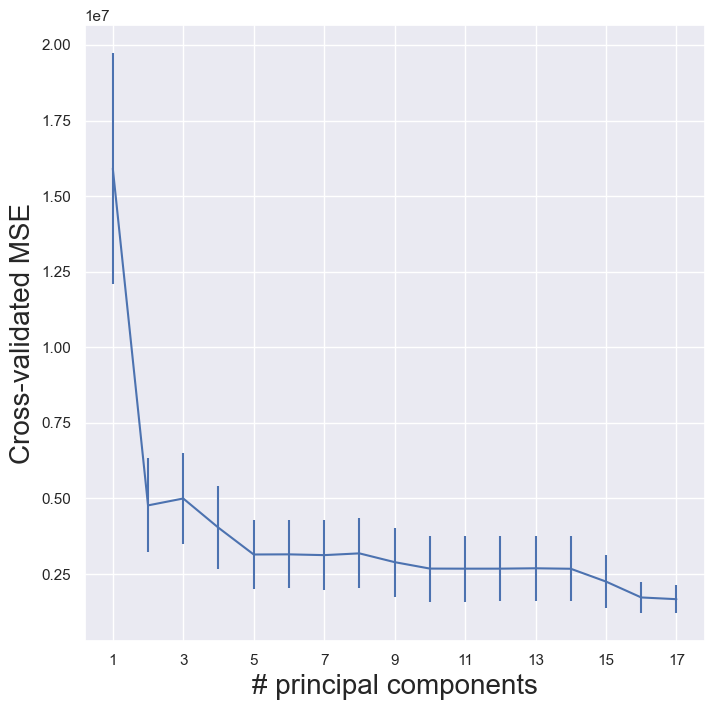

In [28]:
pcr_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['pca__n_components']
ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)
ax.set_xticks(n_comp[::2]);

The number of components  M  that minimizes the MSE is 17

In [29]:
pipe.named_steps['pca'].n_components = grid.best_params_['pca__n_components']
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,17
,copy,True
,whiten,False
,svd_solver,'auto'


In [30]:
pred = pipe.predict(X_test)
pcr_MSE = np.mean((pred - y_test)**2)
pcr_MSE

642753.8976533795

This resulted in a test MSE of $642753.90$ which is the same as fitting a linear regression with all predictors.

That's not surpising since fitting PCR with all p predictors is equivalent to an OLS estimate.

**(f)**

In [31]:
pls = PLSRegression(scale=True)

param_grid = {'n_components':range(1, 18)}
grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

,estimator,PLSRegression()
,param_grid,"{'n_components': range(1, 18)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,16


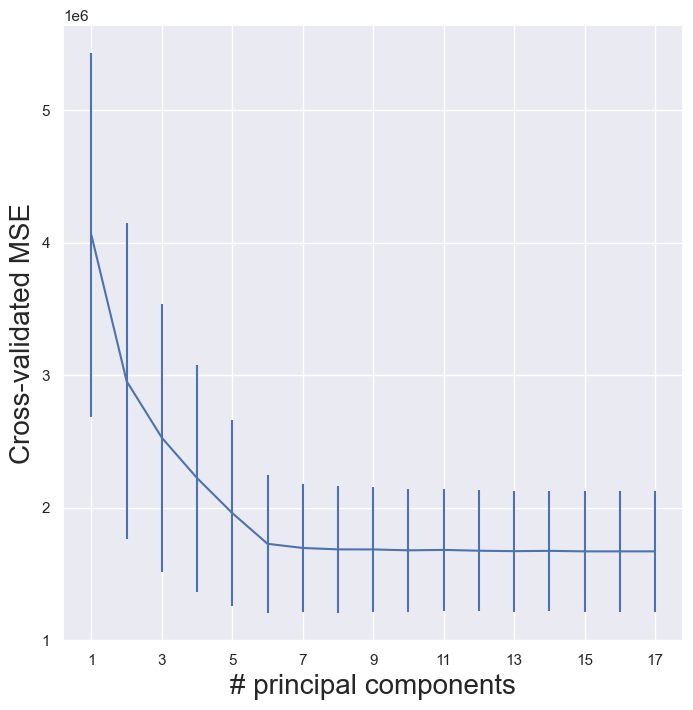

In [32]:
pls_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['n_components']
ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)
ax.set_xticks(n_comp[::2]);

In [33]:
grid.best_params_

{'n_components': 16}

In [34]:
pls.n_components = 16
pls.fit(X_train, y_train)

,n_components,16
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


In [35]:
pred = pls.predict(X_test)
pls_MSE = np.mean((pred - y_test)**2)
pls_MSE

642728.9614907267

Cross-validation chose the value of  M=16 , which resulted in a test MSE of  642728.96 . Slightly lower than the test MSE for PCR and OLS, and the lowest of all models we trained so far.

**(g)**

Comparing the RMSE for the models side to side we can see that PLS comes in first place followed by OLS and PCR (tied for 2nd) with a very small difference in test RMSE, Ridge in 4th place and finally Lasso in last place with a considerably higher test RMSE.

In [36]:
approaches = ['OLS', 'Ridge', 'Lasso', 'PCR', 'PLS']
mse_values = [ols_MSE, ridge_MSE, lasso_MSE, pcr_MSE, pls_MSE]

rmse_values = np.sqrt(mse_values)
for approach, rmse_value in zip(approaches, rmse_values):
    print(f"{approach}: {rmse_value:.2f}")

OLS: 801.72
Ridge: 817.61
Lasso: 843.71
PCR: 801.72
PLS: 801.70


Plotting the results side by side.

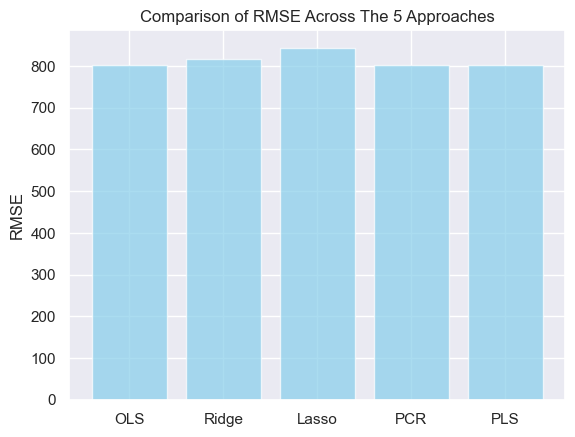

In [37]:
plt.bar(approaches, rmse_values, color="skyblue", alpha=0.7)
plt.ylabel("RMSE")
plt.title("Comparison of RMSE Across The 5 Approaches")
plt.show()

We can see that using our best model (PLS with RMSE = 801.7), our predictions, on average, deviate from the actual number of applications by about 801.7.

In [38]:
801.7/college['Apps'].mean()

0.26708747217842854

That error is roughly $27\%$ of the mean value.

How good of a prediction that is depends on the context and application we plan to use this model for.